# All Vehicle SOC

In [2]:
# Imports
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
#OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}

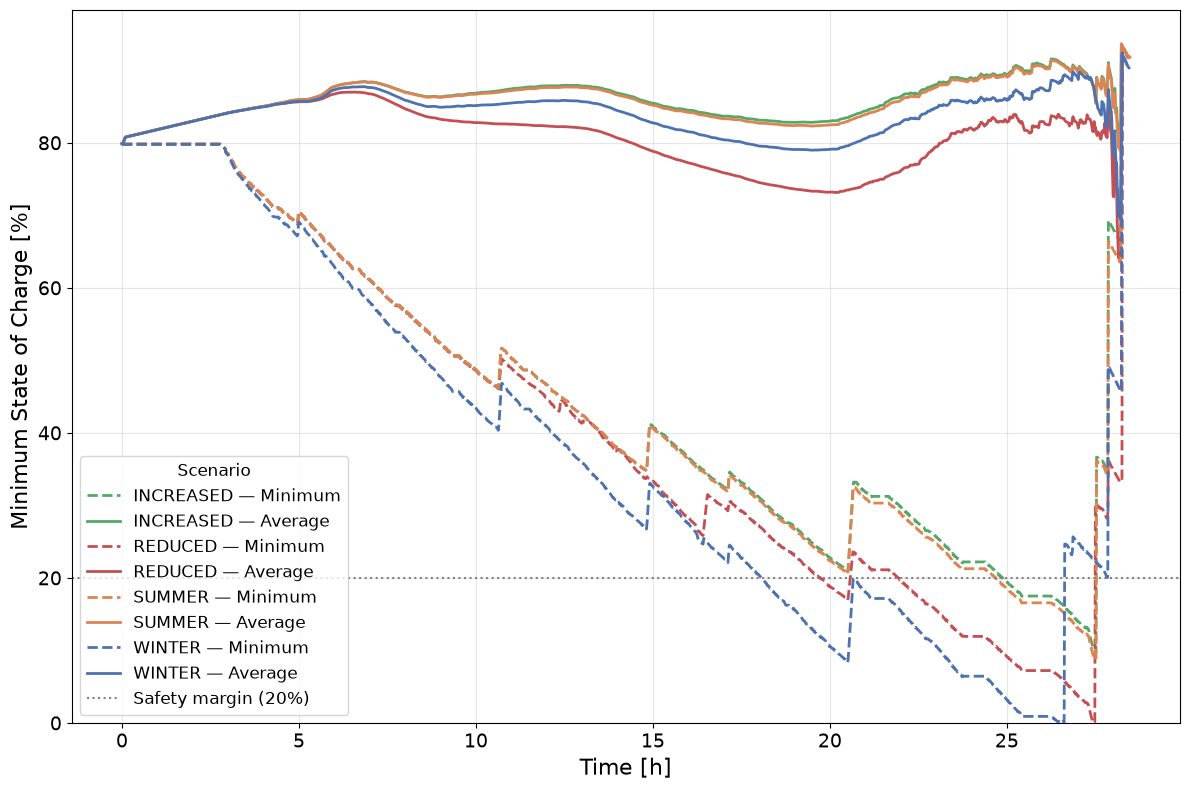


Lowest SOC per scenario:
increased: 9.64% at 27.52 h
reduced: 0.08% at 27.43 h
summer: 8.70% at 27.52 h
winter: 0.04% at 26.55 h
Overall minimum SOC: 0.04%
Scenario-timestep observations at or below 0%: 0
Scenario-timestep observations below 20%: 1227
Saved: C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\FinalPlots\minimum_soc_over_time_by_scenario.pdf


In [7]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        timestep_time, 
        vehicle_id, 
        vehicle_actualBatteryCapacity,
        vehicle_maximumBatteryCapacity,
        scenario, 
        seed
    FROM multirun_battery_aggregated
""").fetchdf()

con.close()

df["soc"] = (
    df["vehicle_actualBatteryCapacity"]
    / df["vehicle_maximumBatteryCapacity"]
    * 100
)

# Calculate the minimum SOC for each scenario at each timestep.
# This takes the worst-performing vehicle across all seeds.
min_soc = (
    df.groupby(["scenario", "timestep_time"])["soc"]
    .min()
    .reset_index()
)

# Calculate average SOC for each scenario at each timestep.
avg_soc = (
    df.groupby(["scenario", "timestep_time"])["soc"]
    .mean()
    .reset_index()
)

min_soc["time_h"] = min_soc["timestep_time"] / 3600
avg_soc["time_h"] = avg_soc["timestep_time"] / 3600


# ------------------------------------------------------------------
# Assign colours to scenarios
# ------------------------------------------------------------------

SCENARIO_COLORS = {
    "winter": PALETTE[0],
    "summer": PALETTE[1],
    "increased": PALETTE[2],
    "reduced": PALETTE[3],
}


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

for scenario in min_soc["scenario"].unique():

    # Minimum SOC — solid line
    scenario_min = min_soc[min_soc["scenario"] == scenario]

    ax.plot(
        scenario_min["time_h"],
        scenario_min["soc"],
        color=SCENARIO_COLORS[scenario],
        linewidth=2,
        linestyle="--",
        label=f"{str(scenario).upper()} — Minimum",
    )

    # Average SOC — dashed line
    scenario_avg = avg_soc[avg_soc["scenario"] == scenario]

    ax.plot(
        scenario_avg["time_h"],
        scenario_avg["soc"],
        color=SCENARIO_COLORS[scenario],
        linewidth=2,
        linestyle="-",
        label=f"{str(scenario).upper()} — Average",
    )


# Safety margin
ax.axhline(
    20,
    color="grey",
    linestyle=":",
    linewidth=1.5,
    label="Safety margin (20%)",
)


ax.set_xlabel("Time [h]", fontsize=16)
ax.set_ylabel("Minimum State of Charge [%]", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

ax.set_ylim(bottom=0)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(title="Scenario", fontsize=12,title_fontsize=12)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "minimum_soc_over_time_by_scenario.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# ------------------------------------------------------------------
# Statistics
# ------------------------------------------------------------------

overall_min_soc = min_soc["soc"].min()
n_depleted = (min_soc["soc"] <= 0).sum()
n_below_safety = (min_soc["soc"] < 20).sum()

# Lowest SOC and corresponding timestep per scenario
lowest_soc_per_scenario = (
    min_soc.loc[
        min_soc.groupby("scenario")["soc"].idxmin()
    ]
    .sort_values("scenario")
)

print("\nLowest SOC per scenario:")
for _, row in lowest_soc_per_scenario.iterrows():
    print(
        f"{row['scenario']}: "
        f"{row['soc']:.2f}% "
        f"at {row['time_h']:.2f} h"
    )

print(f"Overall minimum SOC: {overall_min_soc:.2f}%")
print(f"Scenario-timestep observations at or below 0%: {n_depleted}")
print(f"Scenario-timestep observations below 20%: {n_below_safety}")
print(f"Saved: {OUTPUT_PATH / 'minimum_soc_over_time_by_scenario.pdf'}")

Depleted Bus 1021

### Min SoC with Vehicle over Time

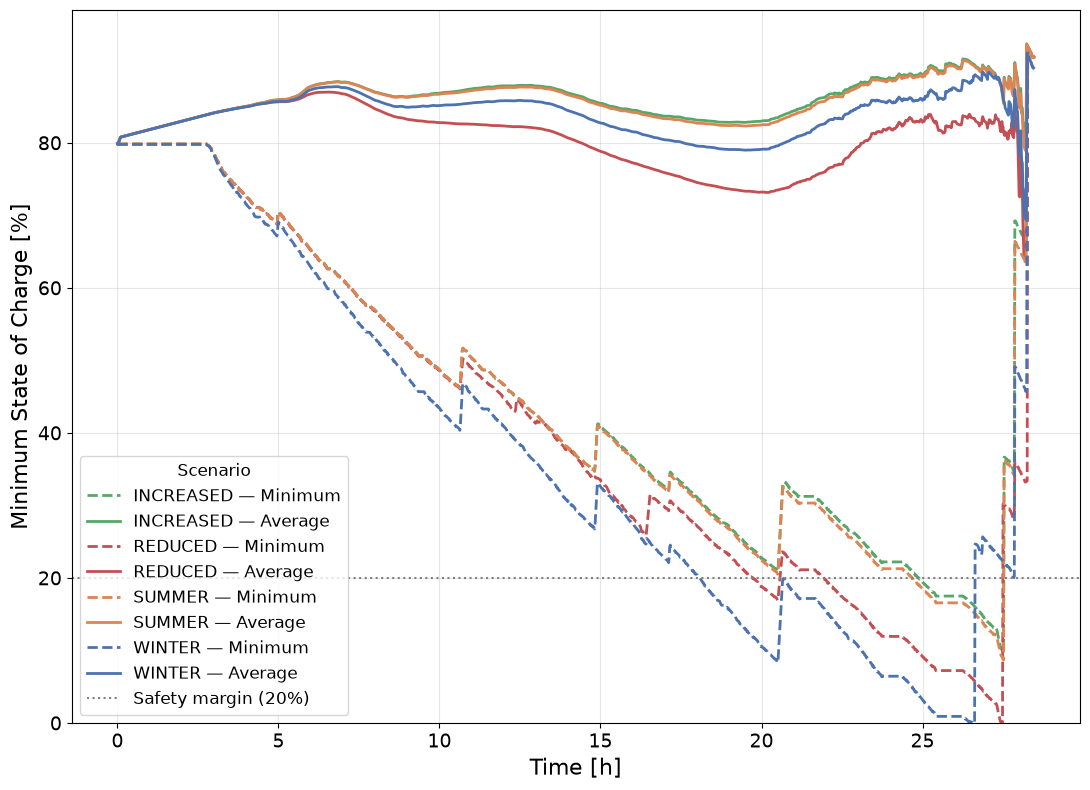


Minimum-SOC vehicle changes:

INCREASED:
  t = 0.00 h | vehicle = bus_1001 | seed = 70 | SOC = 79.77%
  t = 0.02 h | vehicle = bus_1046 | seed = 65 | SOC = 79.76%
  t = 0.03 h | vehicle = bus_3023 | seed = 75 | SOC = 79.79%
  t = 0.05 h | vehicle = bus_3067 | seed = 70 | SOC = 79.81%
  t = 0.07 h | vehicle = bus_1003 | seed = 68 | SOC = 79.82%
  t = 2.78 h | vehicle = bus_2017 | seed = 67 | SOC = 79.72%
  t = 2.93 h | vehicle = bus_1009 | seed = 65 | SOC = 78.77%
  t = 3.23 h | vehicle = bus_1017 | seed = 67 | SOC = 76.45%
  t = 4.02 h | vehicle = bus_1011 | seed = 65 | SOC = 72.49%
  t = 5.00 h | vehicle = bus_1017 | seed = 75 | SOC = 70.48%
  t = 5.18 h | vehicle = bus_1002 | seed = 65 | SOC = 69.47%
  t = 5.23 h | vehicle = bus_1017 | seed = 70 | SOC = 69.20%
  t = 5.25 h | vehicle = bus_1002 | seed = 65 | SOC = 69.13%
  t = 5.42 h | vehicle = bus_1017 | seed = 70 | SOC = 68.22%
  t = 5.43 h | vehicle = bus_1002 | seed = 65 | SOC = 68.19%
  t = 5.45 h | vehicle = bus_1017 | seed = 

In [11]:
con = duckdb.connect(DATABASE_PATH)

df = con.execute("""
    SELECT 
        timestep_time, 
        vehicle_id, 
        vehicle_actualBatteryCapacity,
        vehicle_maximumBatteryCapacity,
        scenario, 
        seed
    FROM multirun_battery_aggregated
""").fetchdf()

con.close()

df["soc"] = (
    df["vehicle_actualBatteryCapacity"]
    / df["vehicle_maximumBatteryCapacity"]
    * 100
)

# Calculate the minimum SOC for each scenario at each timestep.
# This takes the worst-performing vehicle across all seeds.
min_soc = (
    df.groupby(["scenario", "timestep_time"])["soc"]
    .min()
    .reset_index()
)

# Calculate average SOC for each scenario at each timestep.
avg_soc = (
    df.groupby(["scenario", "timestep_time"])["soc"]
    .mean()
    .reset_index()
)

min_soc["time_h"] = min_soc["timestep_time"] / 3600
avg_soc["time_h"] = avg_soc["timestep_time"] / 3600


# ------------------------------------------------------------------
# Assign colours to scenarios
# ------------------------------------------------------------------

SCENARIO_COLORS = {
    "winter": PALETTE[0],
    "summer": PALETTE[1],
    "increased": PALETTE[2],
    "reduced": PALETTE[3],
}


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 8))

for scenario in min_soc["scenario"].unique():

    # Minimum SOC — solid line
    scenario_min = min_soc[min_soc["scenario"] == scenario]

    ax.plot(
        scenario_min["time_h"],
        scenario_min["soc"],
        color=SCENARIO_COLORS[scenario],
        linewidth=2,
        linestyle="--",
        label=f"{str(scenario).upper()} — Minimum",
    )

    # Average SOC — dashed line
    scenario_avg = avg_soc[avg_soc["scenario"] == scenario]

    ax.plot(
        scenario_avg["time_h"],
        scenario_avg["soc"],
        color=SCENARIO_COLORS[scenario],
        linewidth=2,
        linestyle="-",
        label=f"{str(scenario).upper()} — Average",
    )


# Safety margin
ax.axhline(
    20,
    color="grey",
    linestyle=":",
    linewidth=1.5,
    label="Safety margin (20%)",
)


ax.set_xlabel("Time [h]", fontsize=16)
ax.set_ylabel("Minimum State of Charge [%]", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

ax.set_ylim(bottom=0)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(title="Scenario", fontsize=12,title_fontsize=12,)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / "minimum_soc_over_time_by_scenario.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# ------------------------------------------------------------------
# Statistics
# ------------------------------------------------------------------

# AI-generated code — 2026-09-28

# Remove rows where SOC cannot be calculated
df_valid = df.dropna(subset=["soc"])

# Find the row containing the minimum SOC for each
# scenario and timestep.
min_vehicle = (
    df_valid.loc[
        df_valid.groupby(
            ["scenario", "timestep_time"]
        )["soc"].idxmin()
    ]
    [
        [
            "scenario",
            "timestep_time",
            "vehicle_id",
            "seed",
            "soc",
        ]
    ]
    .sort_values(["scenario", "timestep_time"])
)

# Detect when the minimum vehicle changes.
min_vehicle["vehicle_changed"] = (
    min_vehicle.groupby("scenario")["vehicle_id"]
    .transform(lambda x: x.ne(x.shift()))
)

# Print only changes
print("\nMinimum-SOC vehicle changes:")

for scenario, group in min_vehicle.groupby("scenario"):

    print(f"\n{scenario.upper()}:")

    changes = group[group["vehicle_changed"]]

    for _, row in changes.iterrows():

        print(
            f"  t = {row['timestep_time'] / 3600:.2f} h | "
            f"vehicle = {row['vehicle_id']} | "
            f"seed = {row['seed']} | "
            f"SOC = {row['soc']:.2f}%"
        )

overall_min_soc = min_soc["soc"].min()
n_depleted = (min_soc["soc"] <= 0).sum()
n_below_safety = (min_soc["soc"] < 20).sum()

# Lowest SOC and corresponding timestep per scenario
lowest_soc_per_scenario = (
    min_soc.loc[
        min_soc.groupby("scenario")["soc"].idxmin()
    ]
    .sort_values("scenario")
)

print("\nLowest SOC per scenario:")
for _, row in lowest_soc_per_scenario.iterrows():
    print(
        f"{row['scenario']}: "
        f"{row['soc']:.2f}% "
        f"at {row['time_h']:.2f} h"
    )

print(f"Overall minimum SOC: {overall_min_soc:.2f}%")
print(f"Scenario-timestep observations at or below 0%: {n_depleted}")
print(f"Scenario-timestep observations below 20%: {n_below_safety}")
print(f"Saved: {OUTPUT_PATH / 'minimum_soc_over_time_by_scenario.pdf'}")